# 01 EDA: Data Reading and Exploration


## 1. Imports and Path Setup


In [1]:
# Import basic libraries
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set display and plotting style
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

# Detect project root. If current directory is notebooks, go up one level.
current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

raw_data_dir = project_root / 'data' / 'raw'
processed_data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'outputs' / 'figures'

processed_data_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_path = raw_data_dir / 'train.csv'
test_path = raw_data_dir / 'test.csv'
sample_submission_path = raw_data_dir / 'sample_submission.csv'

print(f'Project root: {project_root}')
print(f'train.csv exists: {train_path.exists()} -> {train_path}')
print(f'test.csv exists: {test_path.exists()} -> {test_path}')
print(f'sample_submission.csv exists: {sample_submission_path.exists()} -> {sample_submission_path}')

Project root: D:\LLM_Classification_finetuning
train.csv exists: True -> D:\LLM_Classification_finetuning\data\raw\train.csv
test.csv exists: True -> D:\LLM_Classification_finetuning\data\raw\test.csv
sample_submission.csv exists: True -> D:\LLM_Classification_finetuning\data\raw\sample_submission.csv


## 2. Read Data


In [2]:
# Read raw data without modifying raw files
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')
print(f'sample_submission shape: {sample_submission.shape}')

print('\ntrain columns:')
print(train.columns.tolist())

print('\ntest columns:')
print(test.columns.tolist())

print('\nsample_submission columns:')
print(sample_submission.columns.tolist())

print('\ntrain head(3):')
display(train.head(3))

print('\ntest head(3):')
display(test.head(3))

print('\nsample_submission head(3):')
display(sample_submission.head(3))

train shape: (57477, 9)
test shape: (3, 4)
sample_submission shape: (3, 4)

train columns:
['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']

test columns:
['id', 'prompt', 'response_a', 'response_b']

sample_submission columns:
['id', 'winner_model_a', 'winner_model_b', 'winner_tie']

train head(3):


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""OK, does pineapple b...","[""The question of whether it is morally right to aim for a certain percentage of females in managerial positions is ...","[""As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both of them as quick as...","[""A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, s...","[""A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1....",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call a function?""]","[""Function calling is the process of invoking or executing a function in a programming language. To call a function,...","[""Function calling is the process of invoking a function in a program. A function is a block of code that performs a...",0,0,1



test head(3):


,id,prompt,response_a,response_b
0,136060,"[""I have three oranges today, I ate an orange yesterday. How many oranges do I have?""]","[""You have two oranges today.""]","[""You still have three oranges. Eating an orange yesterday does not affect the number of oranges you have today.""]"
1,211333,"[""You are a mediator in a heated political debate between two opposing parties. Mr Reddy is very hung up on semantic...","[""Thank you for sharing the details of the situation. As a mediator, I understand the importance of finding a middle...","[""Mr Reddy and Ms Blue both have valid points in their arguments. On one hand, Mr Reddy is correct that women are ad..."
2,1233961,"[""How to initialize the classification head when I do transfer learning. For example, I have a pre-trained vision tr...","[""When you want to initialize the classification head for transfer learning, you can follow these steps:\n\n 1. Loa...","[""To initialize the classification head when performing transfer learning, follow these steps:\n\n1. Load the pre-tr..."



sample_submission head(3):


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.333333,0.333333,0.333333
1,211333,0.333333,0.333333,0.333333
2,1233961,0.333333,0.333333,0.333333


## 3. Column Check


In [3]:
# Check whether required columns are complete
required_train_columns = {
    'id',
    'model_a',
    'model_b',
    'prompt',
    'response_a',
    'response_b',
    'winner_model_a',
    'winner_model_b',
    'winner_tie',
}

required_test_columns = {
    'id',
    'prompt',
    'response_a',
    'response_b',
}

missing_train_columns = sorted(required_train_columns - set(train.columns))
missing_test_columns = sorted(required_test_columns - set(test.columns))

if missing_train_columns:
    raise ValueError(f'train.csv missing columns: {missing_train_columns}')

if missing_test_columns:
    raise ValueError(f'test.csv missing columns: {missing_test_columns}')

print('Column check passed.')

Column check passed.


## 4. Text Cleaning


In [4]:
# Convert stringified lists into plain text and clean invalid Unicode characters
def clean_unicode(text):
    if text is None:
        return ''
    if not isinstance(text, str):
        text = str(text)

    try:
        text = text.encode('utf-16', 'surrogatepass').decode('utf-16', 'replace')
    except Exception:
        text = text.encode('utf-8', 'ignore').decode('utf-8', 'ignore')

    text = ''.join(ch for ch in text if not (0xD800 <= ord(ch) <= 0xDFFF))
    return text


def normalize_text(x):
    if x is None:
        return ''

    try:
        if pd.isna(x):
            return ''
    except (TypeError, ValueError):
        pass

    if not isinstance(x, str):
        x = str(x)

    text = x.strip()

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            text = '\n'.join(str(item) for item in parsed if item is not None)
        else:
            text = str(parsed)
    except (ValueError, SyntaxError, TypeError):
        pass

    text = text.replace('\r\n', '\n').replace('\r', '\n').strip()
    text = clean_unicode(text)
    return text


text_columns = ['prompt', 'response_a', 'response_b']

for df_name, df in [('train', train), ('test', test)]:
    for column in text_columns:
        clean_column = f'{column}_clean'
        df[clean_column] = df[column].apply(normalize_text)
    print(f'{df_name}: clean text columns created.')

train: clean text columns created.
test: clean text columns created.


In [5]:
# Check cleaning result on row 0
for column in text_columns:
    clean_column = f'{column}_clean'
    print('=' * 80)
    print(f'{column} raw repr first 500 chars:')
    print(repr(train.loc[0, column])[:500])
    print(f'\n{clean_column} repr first 500 chars:')
    print(repr(train.loc[0, clean_column])[:500])
    print()

prompt raw repr first 500 chars:
'["Is it morally right to try to have a certain percentage of females on managerial positions?","OK, does pineapple belong on a pizza? Relax and give me fun answer."]'

prompt_clean repr first 500 chars:
'Is it morally right to try to have a certain percentage of females on managerial positions?\nOK, does pineapple belong on a pizza? Relax and give me fun answer.'

response_a raw repr first 500 chars:
'["The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination.\\n\\nHere are some arguments in favor of and against such policies:\\n\\n**Arguments in favor:**\\n\\n1. **Correcting Historical Inequities:** Women have historically been underrepresented in leadership roles due to various cultural, institutional, and social barriers. Aiming

response_a_clean repr first 500 chars:
'The question of whet

## 5. Label Conversion


In [6]:
# Convert one-hot labels into label and label_name
label_columns = ['winner_model_a', 'winner_model_b', 'winner_tie']
train['label_sum'] = train[label_columns].sum(axis=1)

invalid_label_rows = train[train['label_sum'] != 1]

if len(invalid_label_rows) > 0:
    print(f'Invalid label rows: {len(invalid_label_rows)}')
    display(invalid_label_rows.head(5))
else:
    print('label_sum check passed. All rows equal 1.')

train['label'] = np.select(
    [
        train['winner_model_a'] == 1,
        train['winner_model_b'] == 1,
        train['winner_tie'] == 1,
    ],
    [0, 1, 2],
    default=-1,
)

label_name_map = {
    0: 'A_win',
    1: 'B_win',
    2: 'tie',
}
train['label_name'] = train['label'].map(label_name_map)

print('Label conversion finished.')
display(train[['winner_model_a', 'winner_model_b', 'winner_tie', 'label_sum', 'label', 'label_name']].head())

label_sum check passed. All rows equal 1.
Label conversion finished.


,winner_model_a,winner_model_b,winner_tie,label_sum,label,label_name
0,1,0,0,1,0,A_win
1,0,1,0,1,1,B_win
2,0,0,1,1,2,tie
3,1,0,0,1,0,A_win
4,0,1,0,1,1,B_win


## 6. Length Feature Engineering


In [7]:
# Build character and word length features from clean text
def word_count(text):
    if not isinstance(text, str) or text == '':
        return 0
    return len(text.split())


def add_length_features(df):
    df['prompt_char_len'] = df['prompt_clean'].str.len()
    df['response_a_char_len'] = df['response_a_clean'].str.len()
    df['response_b_char_len'] = df['response_b_clean'].str.len()
    df['response_len_diff'] = df['response_a_char_len'] - df['response_b_char_len']

    df['prompt_word_len'] = df['prompt_clean'].apply(word_count)
    df['response_a_word_len'] = df['response_a_clean'].apply(word_count)
    df['response_b_word_len'] = df['response_b_clean'].apply(word_count)
    df['response_word_len_diff'] = df['response_a_word_len'] - df['response_b_word_len']
    return df


train = add_length_features(train)
test = add_length_features(test)

length_feature_columns = [
    'prompt_char_len',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
    'prompt_word_len',
    'response_a_word_len',
    'response_b_word_len',
    'response_word_len_diff',
]

print('Length features created.')
display(train[length_feature_columns].head())

Length features created.


,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,159,4459,1200,3259,29,674,205,469
1,192,3096,3592,-496,36,539,579,-40
2,56,884,1796,-912,9,147,297,-150
3,83,3165,1550,1615,18,547,271,276
4,75,1290,760,530,14,234,124,110


## 7. Basic Statistical Analysis


In [8]:
# Label counts and ratios
label_order = ['A_win', 'B_win', 'tie']

label_counts = train['label_name'].value_counts().reindex(label_order)
label_ratios = train['label_name'].value_counts(normalize=True).reindex(label_order)

print('Train label distribution - counts:')
display(label_counts)

print('Train label distribution - ratios:')
display(label_ratios)

print('prompt_char_len describe():')
display(train['prompt_char_len'].describe())

print('response_a_char_len and response_b_char_len describe():')
display(train[['response_a_char_len', 'response_b_char_len']].describe())

Train label distribution - counts:


label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64

Train label distribution - ratios:


label_name
A_win    0.349079
B_win    0.341911
tie      0.309011
Name: proportion, dtype: float64

prompt_char_len describe():


count    57477.000000
mean       352.601301
std       1027.229564
min          3.000000
25%         47.000000
50%         91.000000
75%        233.000000
max      32838.000000
Name: prompt_char_len, dtype: float64

response_a_char_len and response_b_char_len describe():


,response_a_char_len,response_b_char_len
count,57477.000000,57477.000000
mean,1331.500478,1338.383353
std,1463.368161,1485.749404
min,0.000000,0.000000
25%,391.000000,396.000000
50%,1037.000000,1045.000000
75%,1811.000000,1820.000000
max,53299.000000,52403.000000


In [9]:
# Group response length statistics by label
grouped_length_stats = train.groupby('label_name').agg(
    response_a_char_len_mean=('response_a_char_len', 'mean'),
    response_a_char_len_median=('response_a_char_len', 'median'),
    response_b_char_len_mean=('response_b_char_len', 'mean'),
    response_b_char_len_median=('response_b_char_len', 'median'),
    response_len_diff_mean=('response_len_diff', 'mean'),
    response_len_diff_median=('response_len_diff', 'median'),
    response_word_len_diff_mean=('response_word_len_diff', 'mean'),
    response_word_len_diff_median=('response_word_len_diff', 'median'),
).reindex(label_order)

print('Length statistics grouped by label_name:')
display(grouped_length_stats)

print('Train empty text counts:')
empty_text_counts = pd.Series({
    'prompt_clean_empty': (train['prompt_clean'] == '').sum(),
    'response_a_clean_empty': (train['response_a_clean'] == '').sum(),
    'response_b_clean_empty': (train['response_b_clean'] == '').sum(),
})
display(empty_text_counts)

print('Test empty text counts:')
test_empty_text_counts = pd.Series({
    'prompt_clean_empty': (test['prompt_clean'] == '').sum(),
    'response_a_clean_empty': (test['response_a_clean'] == '').sum(),
    'response_b_clean_empty': (test['response_b_clean'] == '').sum(),
})
display(test_empty_text_counts)

Length statistics grouped by label_name:


,response_a_char_len_mean,response_a_char_len_median,response_b_char_len_mean,response_b_char_len_median,response_len_diff_mean,response_len_diff_median,response_word_len_diff_mean,response_word_len_diff_median
label_name,,,,,,,,
A_win,1516.537281,1242.0,1267.384171,963.0,249.153110,150.0,38.646730,24.0
B_win,1247.468604,943.0,1517.226949,1260.0,-269.758345,-155.0,-41.430999,-24.0
tie,1215.449355,890.0,1220.703789,889.0,-5.254434,0.0,-0.533866,0.0


Train empty text counts:


prompt_clean_empty         0
response_a_clean_empty    12
response_b_clean_empty    14
dtype: int64

Test empty text counts:


prompt_clean_empty        0
response_a_clean_empty    0
response_b_clean_empty    0
dtype: int64

## 8. Visualization


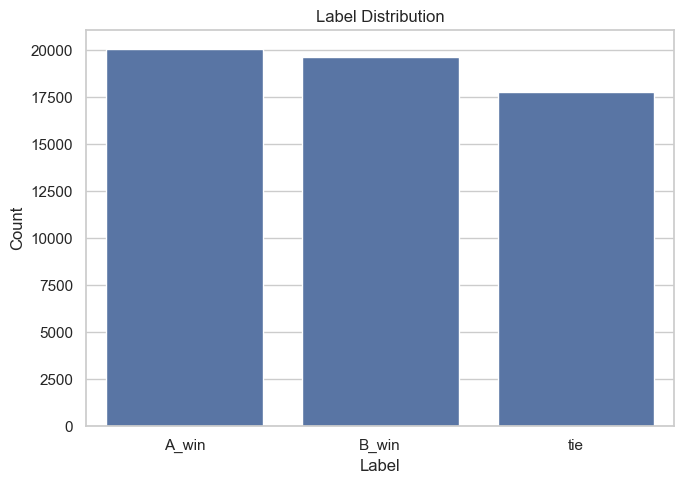

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\label_distribution.png


In [10]:
# 1. Label distribution bar chart
plt.figure(figsize=(7, 5))
sns.countplot(data=train, x='label_name', order=label_order)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()

label_distribution_path = figures_dir / 'label_distribution.png'
plt.savefig(label_distribution_path, dpi=150)
plt.show()
print(f'Saved figure: {label_distribution_path}')

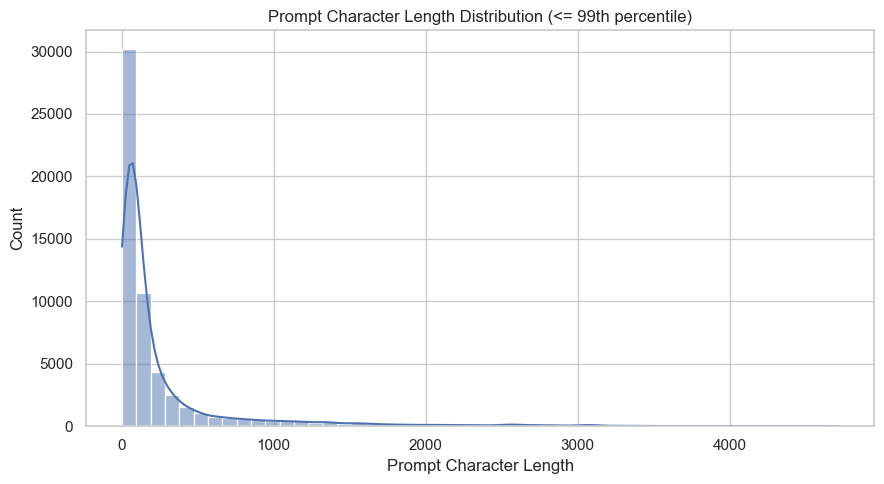

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\prompt_length_distribution.png


In [11]:
# 2. Prompt character length distribution, limited to the 99th percentile
prompt_upper = train['prompt_char_len'].quantile(0.99)
prompt_plot_data = train.loc[train['prompt_char_len'] <= prompt_upper, 'prompt_char_len']

plt.figure(figsize=(9, 5))
sns.histplot(prompt_plot_data, bins=50, kde=True)
plt.title('Prompt Character Length Distribution (<= 99th percentile)')
plt.xlabel('Prompt Character Length')
plt.ylabel('Count')
plt.tight_layout()

prompt_length_path = figures_dir / 'prompt_length_distribution.png'
plt.savefig(prompt_length_path, dpi=150)
plt.show()
print(f'Saved figure: {prompt_length_path}')

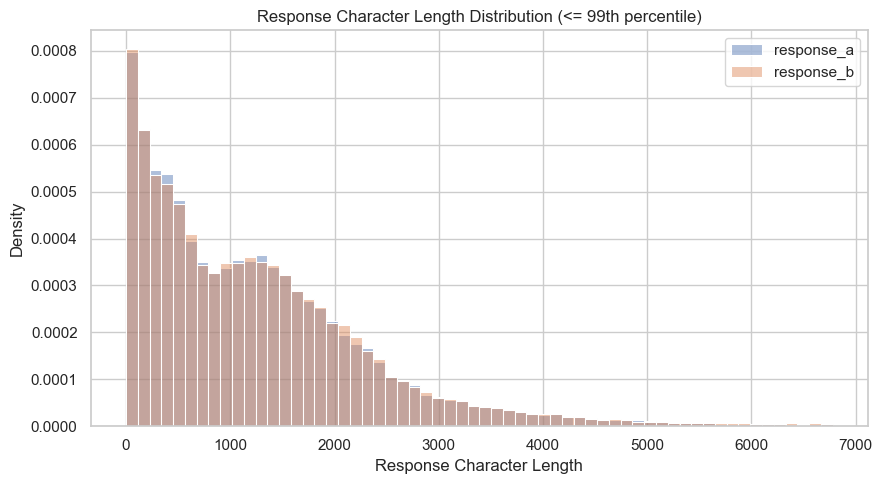

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\response_length_distribution.png


In [12]:
# 3. Compare response_a and response_b character length distributions, limited to the 99th percentile
response_upper = train[['response_a_char_len', 'response_b_char_len']].stack().quantile(0.99)
response_a_plot = train.loc[train['response_a_char_len'] <= response_upper, 'response_a_char_len']
response_b_plot = train.loc[train['response_b_char_len'] <= response_upper, 'response_b_char_len']

plt.figure(figsize=(9, 5))
sns.histplot(response_a_plot, bins=60, stat='density', alpha=0.45, label='response_a')
sns.histplot(response_b_plot, bins=60, stat='density', alpha=0.45, label='response_b')
plt.title('Response Character Length Distribution (<= 99th percentile)')
plt.xlabel('Response Character Length')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()

response_length_path = figures_dir / 'response_length_distribution.png'
plt.savefig(response_length_path, dpi=150)
plt.show()
print(f'Saved figure: {response_length_path}')

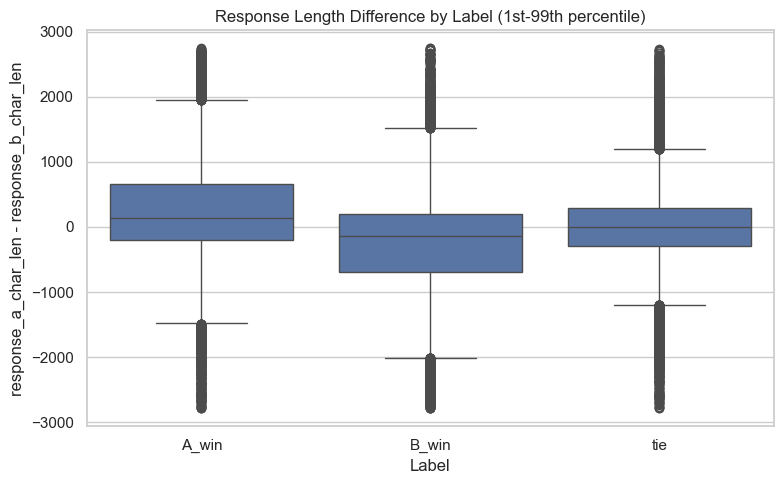

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\response_len_diff_by_label.png


In [13]:
# 4. Boxplot of response_len_diff by label, limited to the 1st-99th percentile range
diff_lower = train['response_len_diff'].quantile(0.01)
diff_upper = train['response_len_diff'].quantile(0.99)
diff_plot_data = train[
    (train['response_len_diff'] >= diff_lower)
    & (train['response_len_diff'] <= diff_upper)
].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=diff_plot_data, x='label_name', y='response_len_diff', order=label_order)
plt.title('Response Length Difference by Label (1st-99th percentile)')
plt.xlabel('Label')
plt.ylabel('response_a_char_len - response_b_char_len')
plt.tight_layout()

response_diff_path = figures_dir / 'response_len_diff_by_label.png'
plt.savefig(response_diff_path, dpi=150)
plt.show()
print(f'Saved figure: {response_diff_path}')

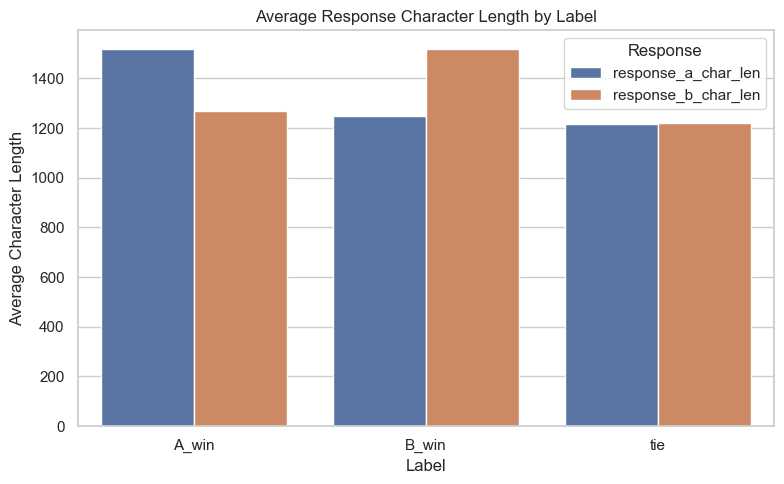

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\avg_response_length_by_label.png


In [14]:
# 5. Compare average response_a and response_b length by label
avg_response_length = (
    train.groupby('label_name')[['response_a_char_len', 'response_b_char_len']]
    .mean()
    .reindex(label_order)
    .reset_index()
    .melt(id_vars='label_name', var_name='response_side', value_name='avg_char_len')
)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_response_length, x='label_name', y='avg_char_len', hue='response_side', order=label_order)
plt.title('Average Response Character Length by Label')
plt.xlabel('Label')
plt.ylabel('Average Character Length')
plt.legend(title='Response')
plt.tight_layout()

avg_response_length_path = figures_dir / 'avg_response_length_by_label.png'
plt.savefig(avg_response_length_path, dpi=150)
plt.show()
print(f'Saved figure: {avg_response_length_path}')

## 9. Save Processed Data


In [15]:
# Save EDA data with clean columns, labels, and length features
train_save_columns = [
    'id',
    'model_a',
    'model_b',
    'winner_model_a',
    'winner_model_b',
    'winner_tie',
    'label_sum',
    'label',
    'label_name',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
] + length_feature_columns

test_save_columns = [
    'id',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
] + length_feature_columns

train_eda_path = processed_data_dir / 'train_eda.csv'
test_eda_path = processed_data_dir / 'test_eda.csv'

train[train_save_columns].to_csv(train_eda_path, index=False, encoding='utf-8-sig')
test[test_save_columns].to_csv(test_eda_path, index=False, encoding='utf-8-sig')

print(f'Saved processed train data: {train_eda_path}')
print(f'Saved processed test data: {test_eda_path}')
print('EDA finished successfully.')

Saved processed train data: D:\LLM_Classification_finetuning\data\processed\train_eda.csv
Saved processed test data: D:\LLM_Classification_finetuning\data\processed\test_eda.csv
EDA finished successfully.


In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

train_eda_path = ROOT / "data" / "processed" / "train_eda.csv"
test_eda_path = ROOT / "data" / "processed" / "test_eda.csv"

train_eda = pd.read_csv(train_eda_path, encoding="utf-8-sig")
test_eda = pd.read_csv(test_eda_path, encoding="utf-8-sig")

print("train_eda shape:", train_eda.shape)
print("test_eda shape:", test_eda.shape)

print("\ncolumns:")
print(train_eda.columns.tolist())

print("\nlabel counts:")
print(train_eda["label_name"].value_counts())

print("\nlabel ratio:")
print(train_eda["label_name"].value_counts(normalize=True))

display(train_eda[
    [
        "id",
        "prompt_clean",
        "response_a_clean",
        "response_b_clean",
        "label",
        "label_name"
    ]
].head(3))

train_eda shape: (57477, 20)
test_eda shape: (3, 12)

columns:
['id', 'model_a', 'model_b', 'winner_model_a', 'winner_model_b', 'winner_tie', 'label_sum', 'label', 'label_name', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']

label counts:
label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64

label ratio:
label_name
A_win    0.349079
B_win    0.341911
tie      0.309011
Name: proportion, dtype: float64


,id,prompt_clean,response_a_clean,response_b_clean,label,label_name
0,30192,Is it morally right to try to have a certain p...,The question of whether it is morally right to...,"As an AI, I don't have personal beliefs or opi...",0,A_win
1,53567,What is the difference between marriage licens...,A marriage license is a legal document that al...,A marriage license and a marriage certificate ...,1,B_win
2,65089,explain function calling. how would you call a...,Function calling is the process of invoking or...,Function calling is the process of invoking a ...,2,tie
